In [9]:
import numpy as np 
import pandas as pd 

import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import OneHotEncoder 
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.metrics import accuracy_score

In [7]:
df = pd.read_csv('../Data/House Price Prediction Dataset.csv')

In [8]:
df.sample(5)

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
1390,1391,4360,1,4,2,1905,Downtown,Good,No,330831
1211,1212,3237,5,1,2,1966,Rural,Poor,Yes,827203
329,330,4175,1,2,3,1904,Urban,Good,Yes,538720
1053,1054,1833,3,4,1,1940,Suburban,Good,Yes,697659
1031,1032,954,5,4,2,2021,Downtown,Poor,No,378085


In [84]:
df.describe()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1000.500000,2786.209500,3.003500,2.55250,1.993500,1961.446000,537676.855000
std,577.494589,1295.146799,1.424606,1.10899,0.809188,35.926695,276428.845719
min,1.000000,501.000000,1.000000,1.00000,1.000000,1900.000000,50005.000000
25%,500.750000,1653.000000,2.000000,2.00000,1.000000,1930.000000,300098.000000
50%,1000.500000,2833.000000,3.000000,3.00000,2.000000,1961.000000,539254.000000
75%,1500.250000,3887.500000,4.000000,4.00000,3.000000,1993.000000,780086.000000
max,2000.000000,4999.000000,5.000000,4.00000,3.000000,2023.000000,999656.000000


In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB


In [86]:
df['Bedrooms'].value_counts()

Bedrooms
1    418
3    406
4    405
5    403
2    368
Name: count, dtype: int64

In [87]:
df['Bathrooms'].value_counts()

Bathrooms
3    524
4    521
2    494
1    461
Name: count, dtype: int64

In [88]:
df['Floors'].value_counts()

Floors
2    691
1    661
3    648
Name: count, dtype: int64

In [89]:
df['Location'].value_counts()

Location
Downtown    558
Urban       485
Suburban    483
Rural       474
Name: count, dtype: int64

In [90]:
df.shape

(2000, 10)

In [91]:
df.columns

Index(['Id', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt',
       'Location', 'Condition', 'Garage', 'Price'],
      dtype='object')

In [92]:
df = df.drop('Id',axis=1)

In [93]:
df.head()

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3592,2,2,3,1938,Downtown,Good,No,266746
3,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [94]:
df.isnull().sum()

Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64

In [95]:
df.duplicated().sum()

np.int64(0)

In [96]:
df.nunique()

Area         1622
Bedrooms        5
Bathrooms       4
Floors          3
YearBuilt     124
Location        4
Condition       4
Garage          2
Price        1999
dtype: int64

In [97]:
df.columns

Index(['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'Location',
       'Condition', 'Garage', 'Price'],
      dtype='object')

In [98]:
df["Location"].value_counts()

Location
Downtown    558
Urban       485
Suburban    483
Rural       474
Name: count, dtype: int64

In [99]:
df.duplicated().sum()

np.int64(0)

In [100]:
df.drop_duplicates(inplace=True)

In [101]:
df.isnull().sum()

Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64

In [102]:
X = df.drop(['Price'],axis=1)
Y = df['Price']

In [103]:
X

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage
0,1360,5,4,3,1970,Downtown,Excellent,No
1,4272,5,4,3,1958,Downtown,Excellent,No
2,3592,2,2,3,1938,Downtown,Good,No
3,966,4,2,2,1902,Suburban,Fair,Yes
4,4926,1,4,2,1975,Downtown,Fair,Yes
...,...,...,...,...,...,...,...,...
1995,4994,5,4,3,1923,Suburban,Poor,No
1996,3046,5,2,1,2019,Suburban,Poor,Yes
1997,1062,5,1,2,1903,Rural,Poor,No
1998,4062,3,1,2,1936,Urban,Excellent,Yes


In [104]:
Y

0       149919
1       424998
2       266746
3       244020
4       636056
         ...  
1995    295620
1996    580929
1997    476925
1998    161119
1999    482525
Name: Price, Length: 2000, dtype: int64

Text(0, 0.5, 'Count')

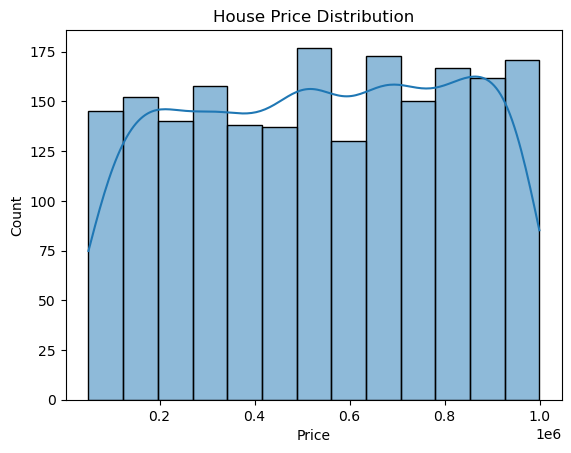

In [105]:
sns.histplot(df['Price'],kde=True)

plt.title("House Price Distribution")
plt.xlabel("Price")
plt.ylabel("Count")

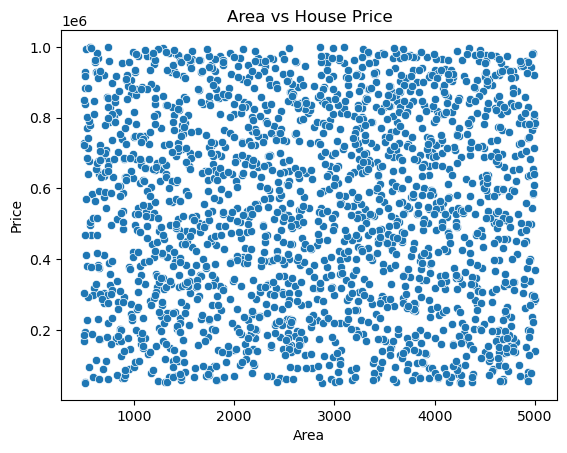

In [106]:
sns.scatterplot(
    x=df["Area"],
    y=df["Price"]
)

plt.title("Area vs House Price")
plt.xlabel("Area")
plt.ylabel("Price")

plt.show()

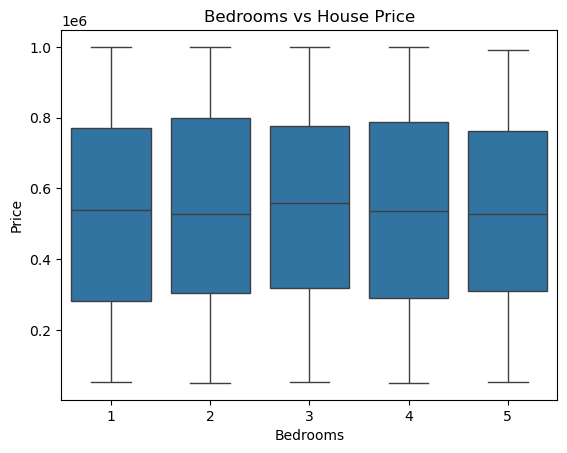

In [107]:
sns.boxplot(
    x=df["Bedrooms"],
    y=df["Price"]
)

plt.title("Bedrooms vs House Price")

plt.show()

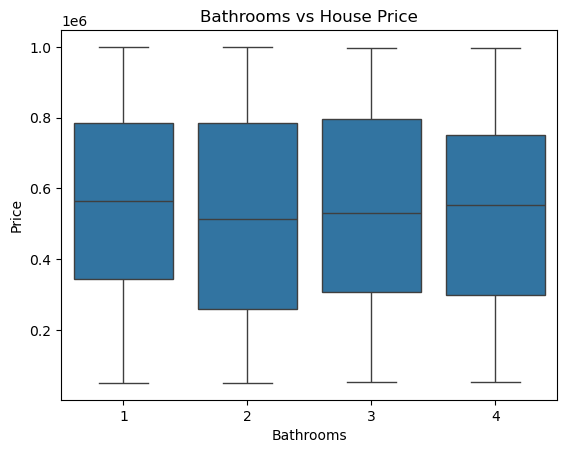

In [108]:
sns.boxplot(
    x=df["Bathrooms"],
    y=df["Price"]
)

plt.title("Bathrooms vs House Price")

plt.show()

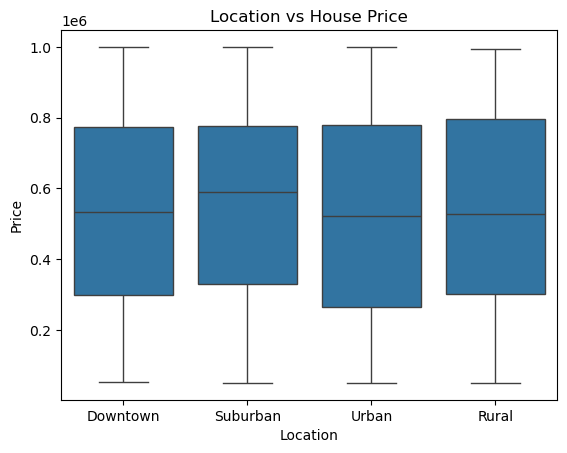

In [109]:
sns.boxplot(
    x=df["Location"],
    y=df["Price"]
)

plt.title("Location vs House Price")

plt.show()

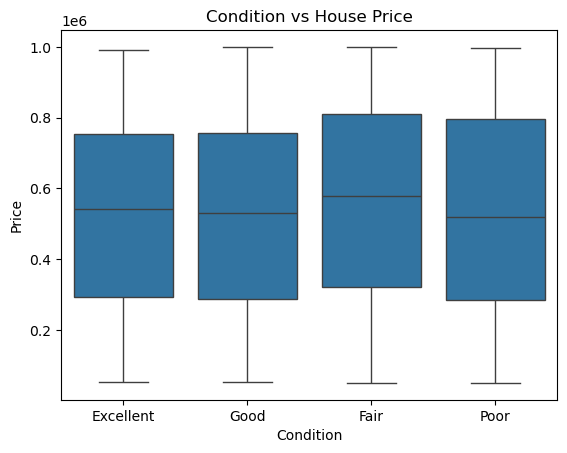

In [110]:
sns.boxplot(
    x=df["Condition"],
    y=df["Price"]
)

plt.title("Condition vs House Price")

plt.show()

In [111]:
df

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3592,2,2,3,1938,Downtown,Good,No,266746
3,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,4926,1,4,2,1975,Downtown,Fair,Yes,636056
...,...,...,...,...,...,...,...,...,...
1995,4994,5,4,3,1923,Suburban,Poor,No,295620
1996,3046,5,2,1,2019,Suburban,Poor,Yes,580929
1997,1062,5,1,2,1903,Rural,Poor,No,476925
1998,4062,3,1,2,1936,Urban,Excellent,Yes,161119


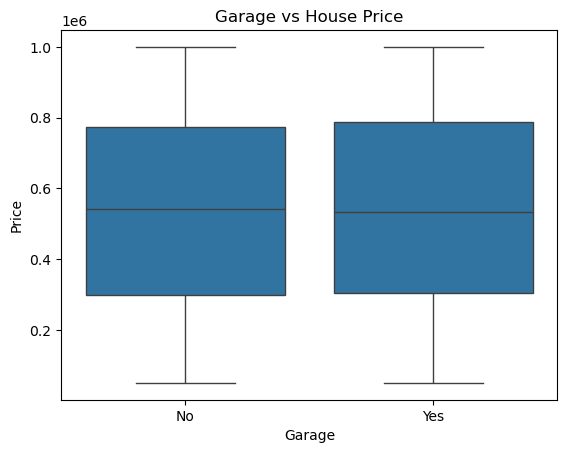

In [112]:
sns.boxplot(
    x=df["Garage"],
    y=df["Price"]
)

plt.title("Garage vs House Price")

plt.show()

In [113]:
corr = df.select_dtypes(
    include='number'
).corr()

Text(0.5, 1.0, 'Correlation Matrix')

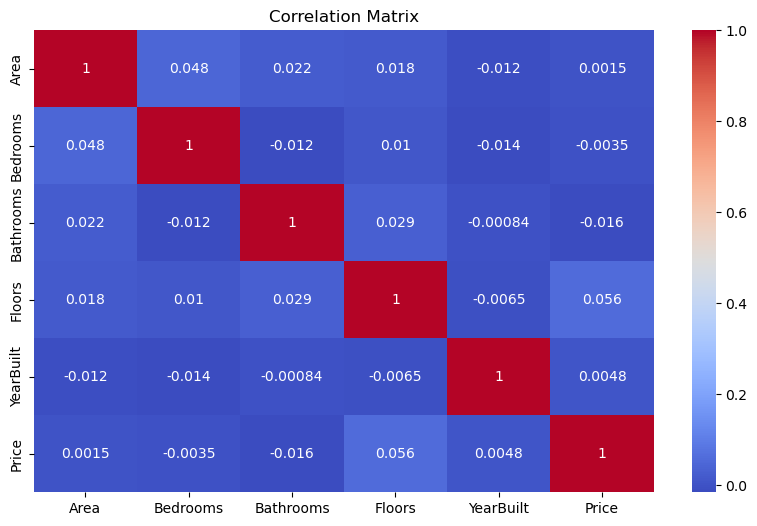

In [114]:
plt.figure(figsize=(10,6))

sns.heatmap(corr,annot=True,cmap="coolwarm")

plt.title("Correlation Matrix")

In [115]:
x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [116]:
x_train

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage
968,4483,4,4,3,1933,Urban,Excellent,No
240,1062,3,3,1,1970,Downtown,Good,No
819,1422,3,4,1,1993,Urban,Good,Yes
692,2658,2,3,1,1972,Rural,Poor,Yes
420,3286,2,4,1,1981,Rural,Excellent,Yes
...,...,...,...,...,...,...,...,...
1130,3483,5,3,3,1931,Downtown,Good,Yes
1294,1747,3,3,2,1941,Downtown,Fair,Yes
860,1484,2,3,3,1973,Downtown,Good,No
1459,3456,5,4,1,1955,Downtown,Good,Yes


In [117]:
numerical_features = [
    "Area",
    "Bedrooms",
    "Bathrooms",
    "Floors",
    "YearBuilt"
]
categorical_features = [
    "Location",
    "Condition",
    "Garage"
]

In [118]:
num_pipeline = Pipeline([
    ("scaler", StandardScaler())
])

In [120]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            'cat', 
            OneHotEncoder(handle_unknown='ignore'),
            categorical_features
        ), 
        (
            'num',
            num_pipeline,
            numerical_features
        )
    ]
)

In [122]:
preprocessor

,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,categories,'auto'
,drop,None
,sparse_output,True


## Model 1 — Linear Regression

In [123]:
model_lr = Pipeline(
    steps=[
        ('preprocessor',preprocessor),
        ('model',LinearRegression())
    ]
)

In [124]:
model_lr

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [125]:
model_lr.fit(x_train,y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [126]:
y_pred = model_lr.predict(x_test)

In [127]:
# MAE tells you the average absolute prediction error. 
mae = mean_absolute_error(y_test,y_pred)

print("MAE:", mae)

MAE: 243241.97758826384


In [128]:
y_test

1860    514764
353     694256
1333     66375
905     650243
1289    223285
         ...  
965     386940
1284    632570
1739    494049
261     562193
535     447530
Name: Price, Length: 400, dtype: int64

In [129]:
y_pred

array([521988.22189839, 549119.31196651, 487101.22235594, 539752.7439933 ,
       553242.24872512, 521375.92025826, 523320.18080583, 578133.64353335,
       545899.64738458, 577368.69940644, 549359.90237922, 583802.8656311 ,
       511024.20843161, 527181.17287186, 502178.93122353, 563657.42139779,
       533851.47058016, 557566.45545641, 578893.4890812 , 522197.01288502,
       535945.37429884, 520333.81440515, 520145.76012635, 589984.6964629 ,
       570910.91251258, 530657.68307139, 524849.79926253, 533833.03412407,
       517535.08657939, 489462.64631857, 471135.44970754, 532885.36922583,
       559703.53345149, 566918.76753933, 505186.85760171, 504126.65238569,
       566525.93875815, 587039.42913431, 533334.54147469, 503067.97932305,
       488794.10065586, 540580.91705316, 538165.7543287 , 538208.1073811 ,
       539782.8193264 , 574195.17961934, 551957.63060142, 537147.22385255,
       531554.19942009, 528480.27403638, 515181.27688738, 549393.77262824,
       567112.62323004, 5

In [130]:
rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

print("RMSE:", rmse)

RMSE: 279859.72583784326


### R² Score Interpretation

- **R² = 1** → Perfect prediction
- **R² = 0** → About as good as predicting the average price
- **R² < 0** → Worse than predicting the average price

In [131]:
r2 = r2_score(y_test, y_pred)

print("R2 Score:", r2)

R2 Score: -0.006717808430749761


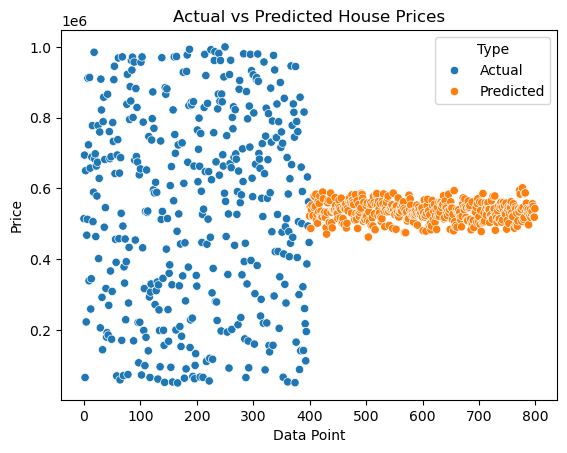

In [132]:
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

# Convert to long format
plot_data = results.melt(
    var_name="Type",
    value_name="Price"
)

sns.scatterplot(
    data=plot_data,
    x=plot_data.index,
    y="Price",
    hue="Type"
)

plt.xlabel("Data Point")
plt.ylabel("Price")
plt.title("Actual vs Predicted House Prices")
plt.show()

In [133]:
## Model 2 — Decision Tree Regressorabs 
dt_model = Pipeline(
    steps=[
         ("preprocessor", preprocessor), 
         ('model',DecisionTreeRegressor(random_state=42))
    ]
)

In [134]:
dt_model

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [135]:
dt_model.fit(x_train,y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [136]:
dt_pred = dt_model.predict(x_test)

In [137]:
dt_pred

array([109263., 421831., 960226., 485485., 620179., 548864.,  69416.,
       201744., 974570., 252252., 514838., 833103., 721844., 578883.,
       137893., 792476., 691157., 549344., 931779., 346508., 702664.,
       135687., 419170., 904531., 294437., 395968., 325536., 601374.,
       295752., 255719., 128743., 948407., 732561., 635009., 397509.,
       654146., 974570., 782119., 959507., 375737., 184974.,  75801.,
       517121., 977325., 965672., 226978., 856903., 266897., 651516.,
       325333., 416099., 314826., 975554., 179745., 782320., 928977.,
       974253., 384192., 783478., 540674., 493888., 455427., 522803.,
       731182., 297145., 279333., 846240., 267885., 954890., 333453.,
       994889., 320041., 833103., 659836., 860763., 974253., 934747.,
        77597.,  92628., 141544., 511531., 562164., 346753., 965986.,
       641759., 171449., 290310., 499704., 980728., 640127., 818026.,
       317014., 178824., 325251., 161186., 845415., 965885., 716217.,
       796355., 7153

In [138]:
dt_r2 = r2_score(y_test, dt_pred)

print("Decision Tree R2:", dt_r2)

Decision Tree R2: -1.1132786887102624


In [139]:
# Model 3 — Random Forest Regressor

In [140]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=100,
                random_state=42
            )
        )
    ]
)

In [141]:
rf_model

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [143]:
rf_model.fit(x_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [144]:
rf_pred = rf_model.predict(x_test)

In [145]:
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest R2:", rf_r2)

Random Forest R2: -0.09948993919118121


In [146]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "R2 Score": [
        r2_score(y_test, y_pred),
        r2_score(y_test, dt_pred),
        r2_score(y_test, rf_pred)
    ]
})

results

,Model,R2 Score
0,Linear Regression,-0.006718
1,Decision Tree,-1.113279
2,Random Forest,-0.099490


# ***The evaluated models performed poorly because the available features showed very weak relationships with the target variable. As a result, the models were unable to learn meaningful patterns for house price prediction***